# 10 — 2D Azimuth × Elevation Maps

**Goal**: extend beamforming from 1D azimuth to 2D (azimuth × elevation),
producing the full hemisphere energy map that an acoustic camera displays.

The Underbrink spiral is a 2D planar array in the x-y plane.  It has aperture
in both horizontal (x) and vertical (y) directions, so it resolves both
azimuth and elevation simultaneously.  For a circularly symmetric spiral,
the 2D PSF should be approximately circular — equal resolution in both
axes at boresight.

**Steering vector** for a far-field source at (az, el):
```
h_n = exp(j·2π·f/c·(sin(az)cos(el)·x_n + sin(el)·y_n)) / √N
```

Key questions:
1. Is the 2D PSF circularly symmetric?  How does HPBW compare in az vs el?
2. Does the 2D map correctly locate sources at off-axis (az, el) positions?
3. How do D&S, MVDR, and CLEAN-SC compare on the 2D map?
4. What is the usable field of view at each frequency?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0
R_MIN  = 0.025
R_MAX  = 0.150
SNR_DB = 20.0
N_SNAP = 256


In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


x_arr, y_arr = underbrink_array(12, 8)
N_MICS = len(x_arr)
print(f'N_MICS = {N_MICS}')


N_MICS = 96


In [3]:
def steering_matrix_2d(x, y, az_grid, el_grid, freq):
    """Returns (N_mics, N_az, N_el).  Far-field 2D steering."""
    az_rad = np.radians(az_grid)  # (N_az,)
    el_rad = np.radians(el_grid)  # (N_el,)
    # Direction cosines on (az, el) grid
    ux = np.sin(az_rad)[:, np.newaxis] * np.cos(el_rad)[np.newaxis, :]  # (N_az, N_el)
    uy = np.ones(len(az_rad))[:, np.newaxis] * np.sin(el_rad)[np.newaxis, :]  # (N_az, N_el)
    # Phase per mic: (N, N_az, N_el)
    phase = 2 * np.pi * freq / C * (
        x[:, np.newaxis, np.newaxis] * ux[np.newaxis] +
        y[:, np.newaxis, np.newaxis] * uy[np.newaxis]
    )
    return np.exp(1j * phase) / np.sqrt(len(x))


def make_csm_2d(x, y, sources_ae, freq, snr_db, n_snap, seed=None):
    """sources_ae: list of (az_deg, el_deg, power) tuples."""
    local_rng = np.random.default_rng(seed)
    N = len(x)
    max_p     = max(p for _, _, p in sources_ae)
    noise_var = max_p / (10 ** (snr_db / 10))
    R = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        y_snap = np.zeros(N, dtype=complex)
        for az, el, power in sources_ae:
            ux = np.sin(np.radians(az)) * np.cos(np.radians(el))
            uy = np.sin(np.radians(el))
            h  = np.exp(1j * 2 * np.pi * freq / C * (ux * x + uy * y)) / np.sqrt(N)
            s  = local_rng.standard_normal() + 1j * local_rng.standard_normal()
            y_snap += np.sqrt(power / 2) * h * s
        noise  = local_rng.standard_normal(N) + 1j * local_rng.standard_normal(N)
        y_snap += np.sqrt(noise_var / 2) * noise
        R += np.outer(y_snap, y_snap.conj())
    return R / n_snap


def psf_2d(x, y, freq, az_grid, el_grid, az0=0.0, el0=0.0):
    """Analytic 2D beam pattern for a source at (az0, el0)."""
    H = steering_matrix_2d(x, y, az_grid, el_grid, freq)   # (N, N_az, N_el)
    N, N_az, N_el = H.shape
    ux0 = np.sin(np.radians(az0)) * np.cos(np.radians(el0))
    uy0 = np.sin(np.radians(el0))
    h0  = np.exp(1j * 2 * np.pi * freq / C * (ux0 * x + uy0 * y)) / np.sqrt(N)
    psf = np.abs(H.reshape(N, -1).conj().T @ h0) ** 2  # (N_az*N_el,)
    return psf.reshape(N_az, N_el)


def beamform_ds_2d(x, y, R, freq, az_grid, el_grid):
    H = steering_matrix_2d(x, y, az_grid, el_grid, freq)
    N, N_az, N_el = H.shape
    H_flat = H.reshape(N, -1)
    P = np.real(np.sum(H_flat.conj() * (R @ H_flat), axis=0))
    return P.reshape(N_az, N_el)


def beamform_mvdr_2d(x, y, R, freq, az_grid, el_grid, diag_load=0.01):
    N = R.shape[0]
    R_loaded = R + diag_load * np.trace(R) / N * np.eye(N)
    R_inv = inv(R_loaded)
    H = steering_matrix_2d(x, y, az_grid, el_grid, freq)
    H_flat = H.reshape(N, -1)
    denom = np.real(np.sum(H_flat.conj() * (R_inv @ H_flat), axis=0))
    return (1.0 / np.maximum(denom, 1e-300)).reshape(len(az_grid), len(el_grid))


def clean_sc_2d(x, y, R, freq, az_grid, el_grid, n_iter=40, loop_gain=0.5):
    H = steering_matrix_2d(x, y, az_grid, el_grid, freq)
    N, N_az, N_el = H.shape
    H_flat = H.reshape(N, -1)
    R_w    = R.copy()
    clean  = np.zeros(N_az * N_el)
    for _ in range(n_iter):
        P = np.real(np.sum(H_flat.conj() * (R_w @ H_flat), axis=0))
        k = np.argmax(P)
        g = R_w @ H_flat[:, k]
        R_w -= loop_gain * np.outer(g, g.conj())
        clean[k] += loop_gain * np.real(g.conj() @ g)
    return clean.reshape(N_az, N_el)


def db_norm(P):
    return 10 * np.log10(np.maximum(P / P.max(), 1e-10))


def measure_hpbw(grid, profile):
    """Half-power beamwidth from a 1-D normalised power profile."""
    half = profile.max() / 2
    above = np.where(profile >= half)[0]
    if len(above) < 2:
        return None
    return grid[above[-1]] - grid[above[0]]


# Scan grid: 91 pts in each dimension, 1.5° step
az_grid = np.linspace(-60, 60, 91)
el_grid = np.linspace(-60, 60, 91)
print(f'2D grid: {len(az_grid)} × {len(el_grid)} = {len(az_grid)*len(el_grid)} pts')


2D grid: 91 × 91 = 8281 pts


## 1 — 2D Beam Pattern (PSF) at 1, 4, 8 kHz

Analytic PSF for a point source at boresight (az=0°, el=0°).  The Underbrink
spiral is symmetric about the origin, so the PSF should be approximately
circular — equal HPBW in azimuth and elevation.


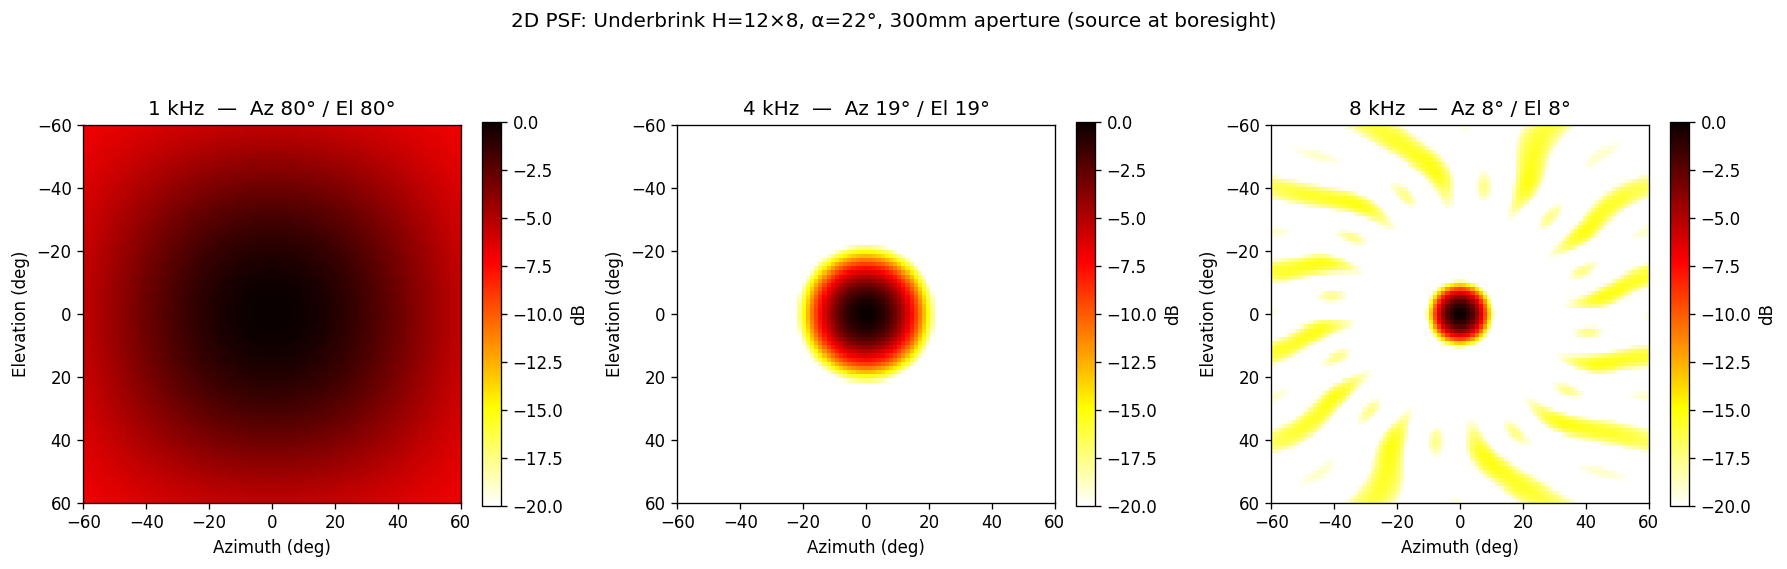

           Az HPBW (°)  El HPBW (°)
Freq (Hz)                          
1000              80.0         80.0
4000              18.7         18.7
8000               8.0          8.0


In [4]:
freqs    = [1000, 4000, 8000]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
extent   = [az_grid[0], az_grid[-1], el_grid[-1], el_grid[0]]

hpbw_table = []
for ax, freq in zip(axes, freqs):
    P = psf_2d(x_arr, y_arr, freq, az_grid, el_grid)
    P_db = db_norm(P)
    im = ax.imshow(P_db.T, extent=extent, aspect='equal',
                   vmin=-20, vmax=0, cmap='hot_r', origin='upper')
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('Elevation (deg)')
    ax.set_title(f'{freq/1000:.0f} kHz')
    plt.colorbar(im, ax=ax, label='dB', fraction=0.046)

    # HPBW slices
    el0_idx = np.argmin(np.abs(el_grid))
    az0_idx = np.argmin(np.abs(az_grid))
    hpbw_az = measure_hpbw(az_grid, P[:, el0_idx])
    hpbw_el = measure_hpbw(el_grid, P[az0_idx, :])
    hpbw_table.append({'Freq (Hz)': freq,
                        'Az HPBW (°)': round(hpbw_az, 1) if hpbw_az else '>120',
                        'El HPBW (°)': round(hpbw_el, 1) if hpbw_el else '>120'})
    label = f'Az {hpbw_az:.0f}° / El {hpbw_el:.0f}°' if hpbw_az else 'Omnidirectional'
    ax.set_title(f'{freq/1000:.0f} kHz  —  {label}')

plt.suptitle('2D PSF: Underbrink H=12×8, α=22°, 300mm aperture (source at boresight)')
plt.tight_layout()
plt.savefig('2d_psf_freq.png', dpi=150, bbox_inches='tight')
plt.show()

df_hpbw = pd.DataFrame(hpbw_table).set_index('Freq (Hz)')
print(df_hpbw.to_string())


## 2 — Algorithm Comparison: D&S vs MVDR vs CLEAN-SC

Two equal-power sources: (az=−20°, el=+10°) and (az=+15°, el=−15°).
SNR=20 dB, N_SNAP=256, f=4 kHz.
True source positions marked with cyan crosses.


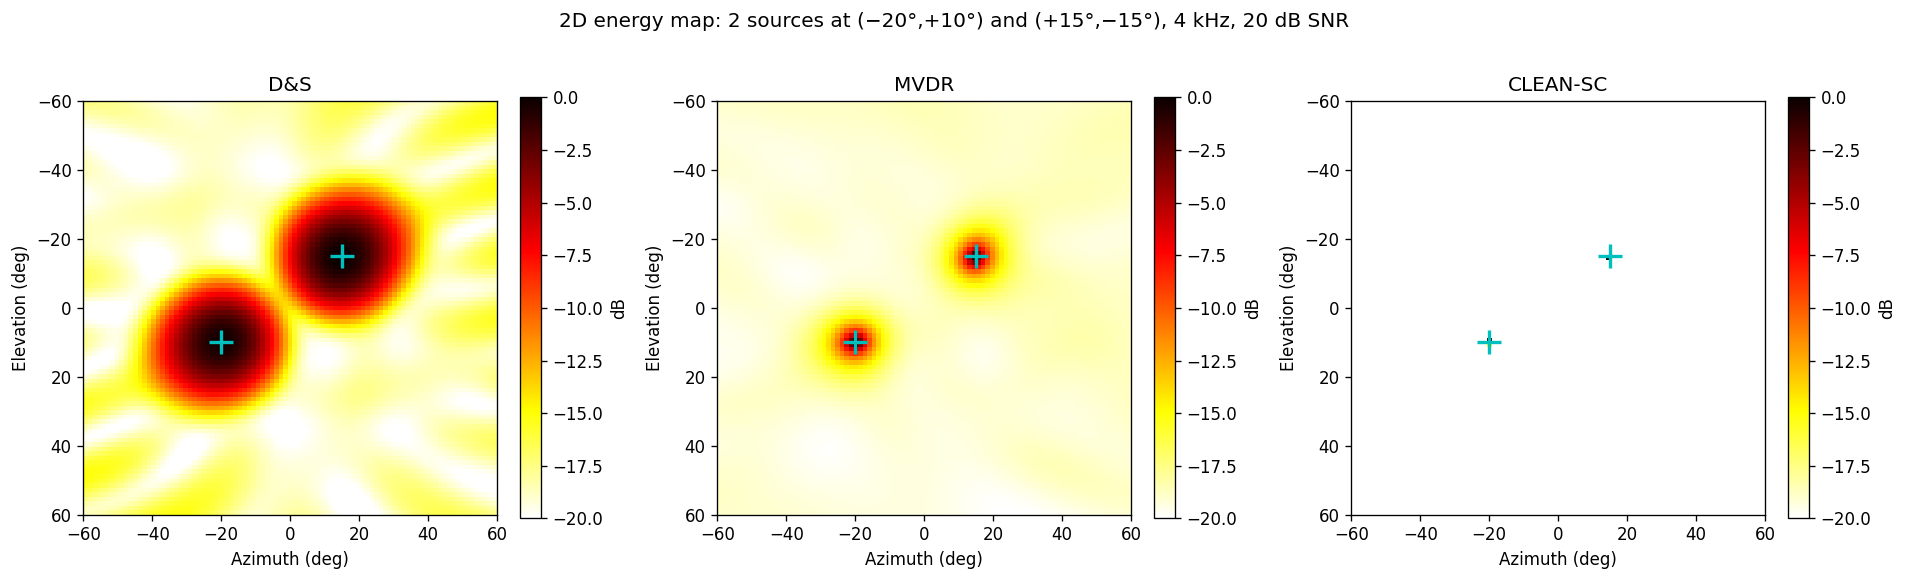

D&S: strongest peak at az=14.7°, el=-14.7°
MVDR: strongest peak at az=14.7°, el=-14.7°
CLEAN-SC: strongest peak at az=14.7°, el=-14.7°


In [5]:
FREQ     = 4000.0
sources  = [(-20.0, 10.0, 1.0), (15.0, -15.0, 1.0)]
R_src    = make_csm_2d(x_arr, y_arr, sources, FREQ, SNR_DB, N_SNAP, seed=10)

P_ds    = beamform_ds_2d(x_arr, y_arr, R_src, FREQ, az_grid, el_grid)
P_mv    = beamform_mvdr_2d(x_arr, y_arr, R_src, FREQ, az_grid, el_grid)
P_cl    = clean_sc_2d(x_arr, y_arr, R_src, FREQ, az_grid, el_grid)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
extent = [az_grid[0], az_grid[-1], el_grid[-1], el_grid[0]]

for ax, P, title in [
    (axes[0], P_ds, 'D&S'),
    (axes[1], P_mv, 'MVDR'),
    (axes[2], P_cl, 'CLEAN-SC'),
]:
    im = ax.imshow(db_norm(P).T, extent=extent, aspect='equal',
                   vmin=-20, vmax=0, cmap='hot_r', origin='upper')
    for az_t, el_t, _ in sources:
        ax.plot(az_t, el_t, 'c+', markersize=14, markeredgewidth=2)
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('Elevation (deg)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='dB', fraction=0.046)

plt.suptitle(f'2D energy map: 2 sources at (−20°,+10°) and (+15°,−15°), '
             f'{FREQ/1000:.0f} kHz, {SNR_DB:.0f} dB SNR')
plt.tight_layout()
plt.savefig('2d_algo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Report peak locations
for P, lbl in [(P_ds, 'D&S'), (P_mv, 'MVDR'), (P_cl, 'CLEAN-SC')]:
    idx = np.unravel_index(np.argmax(P), P.shape)
    print(f'{lbl}: strongest peak at az={az_grid[idx[0]]:.1f}°, el={el_grid[idx[1]]:.1f}°')


## 3 — Azimuth vs Elevation HPBW Symmetry

For a circularly symmetric array, HPBW should be equal in azimuth and elevation
at boresight.  Measure both at each octave frequency to verify.


In [6]:
freq_list = [500, 1000, 2000, 4000, 8000]
rows = []
for freq in freq_list:
    P = psf_2d(x_arr, y_arr, freq, az_grid, el_grid)
    el0 = np.argmin(np.abs(el_grid))
    az0 = np.argmin(np.abs(az_grid))
    haz = measure_hpbw(az_grid, P[:, el0])
    hel = measure_hpbw(el_grid, P[az0, :])
    rows.append({
        'Freq (Hz)': freq,
        'Az HPBW (°)': round(haz, 1) if haz else '>120',
        'El HPBW (°)': round(hel, 1) if hel else '>120',
        'Az/El ratio': round(haz / hel, 3) if (haz and hel) else 'n/a',
    })

df_sym = pd.DataFrame(rows).set_index('Freq (Hz)')
print(df_sym.to_string())
print()
print('Az/El ratio = 1.0 indicates perfect circular symmetry.')


           Az HPBW (°)  El HPBW (°)  Az/El ratio
Freq (Hz)                                       
500              120.0        120.0          1.0
1000              80.0         80.0          1.0
2000              37.3         37.3          1.0
4000              18.7         18.7          1.0
8000               8.0          8.0          1.0

Az/El ratio = 1.0 indicates perfect circular symmetry.


## 4 — Source Localisation Accuracy Across the FOV

Single source at five positions spanning the FOV.  Report D&S and CLEAN-SC
peak locations vs true positions at 4 kHz.


In [7]:
test_sources = [
    ( 0.0,   0.0, 'Boresight'),
    (25.0,   0.0, 'Az=25°, El=0°'),
    ( 0.0,  25.0, 'Az=0°, El=25°'),
    (30.0,  20.0, 'Az=30°, El=20°'),
    (-40.0, -15.0, 'Az=−40°, El=−15°'),
]

rows_loc = []
for i, (az_t, el_t, label) in enumerate(test_sources):
    R = make_csm_2d(x_arr, y_arr, [(az_t, el_t, 1.0)], FREQ, SNR_DB, N_SNAP,
                    seed=i * 100 + 1)
    for alg, fn in [('D&S', beamform_ds_2d), ('CLEAN-SC', clean_sc_2d)]:
        P = fn(x_arr, y_arr, R, FREQ, az_grid, el_grid)
        idx = np.unravel_index(np.argmax(P), P.shape)
        az_est, el_est = az_grid[idx[0]], el_grid[idx[1]]
        rows_loc.append({
            'Position': label,
            'Algorithm': alg,
            'Az error (°)': round(abs(az_est - az_t), 1),
            'El error (°)': round(abs(el_est - el_t), 1),
            'Total error (°)': round(np.sqrt((az_est-az_t)**2 + (el_est-el_t)**2), 2),
        })

df_loc = pd.DataFrame(rows_loc)
print(df_loc.to_string(index=False))


        Position Algorithm  Az error (°)  El error (°)  Total error (°)
       Boresight       D&S           0.0           0.0             0.00
       Boresight  CLEAN-SC           0.0           0.0             0.00
   Az=25°, El=0°       D&S           0.3           0.0             0.33
   Az=25°, El=0°  CLEAN-SC           0.3           0.0             0.33
   Az=0°, El=25°       D&S           0.0           0.3             0.33
   Az=0°, El=25°  CLEAN-SC           0.0           0.3             0.33
  Az=30°, El=20°       D&S           0.7           0.0             0.67
  Az=30°, El=20°  CLEAN-SC           0.7           0.0             0.67
Az=−40°, El=−15°       D&S           0.0           0.3             0.33
Az=−40°, El=−15°  CLEAN-SC           0.0           0.3             0.33


## Summary


In [8]:
print('=== 2D PSF HPBW (azimuth and elevation) ===')
print(df_sym.to_string())
print()
print('=== Source localisation across the FOV (4 kHz, 20 dB SNR) ===')
print(df_loc.to_string(index=False))


=== 2D PSF HPBW (azimuth and elevation) ===
           Az HPBW (°)  El HPBW (°)  Az/El ratio
Freq (Hz)                                       
500              120.0        120.0          1.0
1000              80.0         80.0          1.0
2000              37.3         37.3          1.0
4000              18.7         18.7          1.0
8000               8.0          8.0          1.0

=== Source localisation across the FOV (4 kHz, 20 dB SNR) ===
        Position Algorithm  Az error (°)  El error (°)  Total error (°)
       Boresight       D&S           0.0           0.0             0.00
       Boresight  CLEAN-SC           0.0           0.0             0.00
   Az=25°, El=0°       D&S           0.3           0.0             0.33
   Az=25°, El=0°  CLEAN-SC           0.3           0.0             0.33
   Az=0°, El=25°       D&S           0.0           0.3             0.33
   Az=0°, El=25°  CLEAN-SC           0.0           0.3             0.33
  Az=30°, El=20°       D&S           0.7      